# Conversão de `main.py` para Jupyter Notebook

Este notebook é uma cópia de `main.py`, organizada em **células separadas** para permitir que cada trecho de código seja executado isoladamente.


## 1) Imports e configurações iniciais

Importe as dependências necessárias (equivalente ao topo de `main.py`).


In [2]:
from utils import encontrar_pdfs, regra_divisao, extrair_tabela_por_linhas_vermelhas
from leitor_pdf import dividir_pdf
import pdfplumber, json
import importlib
import utils
importlib.reload(utils)

print("Imports carregados")


Imports carregados


## 2) Listar PDFs e iterar sobre eles

Este bloco corresponde ao loop principal de `main.py` que percorre os arquivos na pasta `arquivos/pastateste`.


In [3]:
pdf_folder = "arquivos/pastateste"

pdfs_encontrados = [f for f in encontrar_pdfs(pdf_folder) if f.lower().endswith(".pdf")]
print(f"Encontrados {len(pdfs_encontrados)} PDFs em {pdf_folder}")
for arquivo in pdfs_encontrados:
    print("-", arquivo)


Encontrados 1 PDFs em arquivos/pastateste
- arquivos/pastateste/Tormenta20-Edicao-Jogo-do-Ano-v1.3.pdf


## 3) Processar cada PDF (célula principal)

O bloco a seguir corresponde ao corpo do `for` em `main.py`. Ele abre cada PDF, define classes auxiliares e realiza a extração.


In [4]:
# Escolha um PDF para analisar (altere o índice conforme necessário)
idx = 0
arquivo = pdfs_encontrados[idx]
print(f"Analisando: {arquivo}")


Analisando: arquivos/pastateste/Tormenta20-Edicao-Jogo-do-Ano-v1.3.pdf


In [4]:
# Definições de classes para metadados de texto (originais em `main.py`)

class Topico:
    def __init__(self, texto, tamanho_fonte=None, cor_fonte=None):
        self.texto = texto
        self.tamanho_fonte = tamanho_fonte
        self.cor_fonte = cor_fonte if cor_fonte is None else cor_fonte

        # Garantir que as cores sejam arrays de 3 posições [R, G, B]
        if self.cor_fonte is not None and not isinstance(self.cor_fonte, list):
            self.cor_fonte = [0, 0, 0]


class Titulo:
    def __init__(self, texto, tamanho_fonte=None, cor_fonte=None):
        self.texto = texto
        self.tamanho_fonte = tamanho_fonte
        self.cor_fonte = cor_fonte if cor_fonte is None else cor_fonte

        # Garantir que as cores sejam arrays de 3 posições [R, G, B]
        if self.cor_fonte is not None and not isinstance(self.cor_fonte, list):
            self.cor_fonte = [0, 0, 0]


class Subtitulo:
    def __init__(self, texto, tamanho_fonte=None, cor_fonte=None):
        self.texto = texto
        self.tamanho_fonte = tamanho_fonte
        self.cor_fonte = cor_fonte if cor_fonte is None else cor_fonte

        # Garantir que as cores sejam arrays de 3 posições [R, G, B]
        if self.cor_fonte is not None and not isinstance(self.cor_fonte, list):
            self.cor_fonte = [0, 0, 0]


class Tabela:
    def __init__(self, texto, tamanho_fonte=None, cor_fonte=None):
        self.texto = texto
        self.tamanho_fonte = tamanho_fonte
        self.cor_fonte = cor_fonte if cor_fonte is None else cor_fonte

        # Garantir que as cores sejam arrays de 3 posições [R, G, B]
        if self.cor_fonte is not None and not isinstance(self.cor_fonte, list):
            self.cor_fonte = [0, 0, 0]


{'x0': 289.134, 'y0': 346.182, 'x1': 345.827, 'y1': 346.182, 'width': 56.692999999999984, 'height': 0, 'pts': [(289.134, 403.048), (345.827, 403.048), (345.827, 433.346), (289.134, 433.346)], 'linewidth': 0, 'stroke': False, 'fill': True, 'evenodd': False, 'stroking_color': 0, 'non_stroking_color': (0.874, 0.844, 0.83), 'mcid': None, 'tag': None, 'object_type': 'rect_edge', 'page_number': 24, 'path': [('m', (289.134, 403.048)), ('l', (345.827, 403.048)), ('l', (345.827, 433.346)), ('l', (289.134, 433.346)), ('h',)], 'dash': None, 'top': 433.346, 'bottom': 433.346, 'doctop': 18362.489999999998, 'orientation': 'h'}


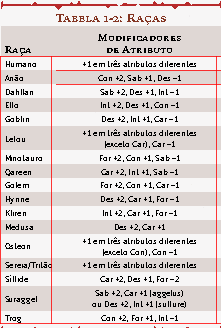

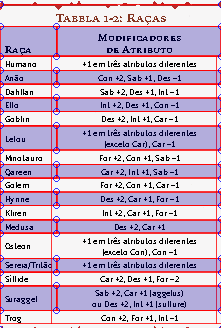

Tabela 1-2: Raças
Modificadores
Raça de Atributo
Humano +1 em três atributos diferentes
Anão Con +2, Sab +1, Des –1
Dahllan Sab +2, Des +1, Int –1
Elfo Int +2, Des +1, Con –1
Goblin Des +2, Int +1, Car –1
+1 em três atributos diferentes
Lefou
(exceto Car), Car –1
Minotauro For +2, Con +1, Sab –1
Qareen Car +2, Int +1, Sab –1
Golem For +2, Con +1, Car –1
Hynne Des +2, Car +1, For –1
Kliren Int +2, Car +1, For –1
Medusa Des +2, Car +1
+1 em três atributos diferentes
Osteon
(exceto Con), Con –1
Sereia/Tritão +1 em três atributos diferentes
Sílfide Car +2, Des +1, For –2
Sab +2, Car +1 (aggelus)
Suraggel
ou Des +2, Int +1 (sulfure)
Trog Con +2, For +1, Int –1


In [114]:
# Seleção de página e recorte das colunas

# Ajuste esse
#  índice para a página desejada (0-index)
pagina_idx = 23

from IPython.display import display

with pdfplumber.open(arquivo) as pdf:
    page = pdf.pages[pagina_idx]

    cropped = extrair_tabela_por_linhas_vermelhas(page)

    # if cropped is not None:
    #     display(cropped.to_image(resolution=150))
    # else:
    #     print("Não foi possível encontrar a área da tabela na página.")
    
    lines = [
            ((cropped.rects[0]['x0'], cropped.rects[0]['bottom']),(cropped.rects[-2]['x0'], cropped.bbox[-1]-5)),
            ((cropped.rects[-2]['x0'], cropped.bbox[-1]-5), (cropped.rects[-1]['x1'], cropped.bbox[-1]-5)),
            ((cropped.rects[0]['x1']-5, cropped.rects[0]['bottom']),(cropped.rects[-2]['x1']-5, cropped.bbox[-1]-5)),
            ((cropped.rects[-1]['x1']-5, cropped.bbox[-1]-5),(cropped.rects[1]['x1']-5, cropped.rects[1]['bottom'])),
            ((cropped.rects[1]['x1'], cropped.rects[1]['bottom']),(cropped.rects[0]['x0'], cropped.rects[0]['bottom']))
        ]

    print(cropped.rect_edges[1])

    destac_rects = cropped.to_image().draw_line(cropped.rect_edges[12])
    destac_rects = destac_rects.draw_lines(lines)
    display(destac_rects)

    table_settings = {
        "vertical_strategy": "text",
        "horizontal_strategy": "text",
        "snap_y_tolerance": 6,  # Aumentei levemente para garantir que textos de 2 linhas fiquem juntos
        "join_tolerance": 5,
        "snap_x_tolerance": 5
    }

    display(destac_rects.debug_tablefinder(table_settings={}))

for linha in cropped.extract_text_lines():
    print(linha['text'])


In [ ]:
# Iterar sobre as linhas extraídas e detectar padrões
largura = page.width
altura = page.height-32 # cortar rodapé

coluna_esquerda = page.crop((0, 0, largura/2, altura))
coluna_direita = page.crop((largura/2, 0, largura, altura))

pagina_completa = coluna_esquerda.extract_text_lines() + coluna_direita.extract_text_lines()

for linha in pagina_completa:
    R, G, B = (
        linha["chars"][0]["non_stroking_color"][0],
        linha["chars"][0]["non_stroking_color"][1],
        linha["chars"][0]["non_stroking_color"][2],
    )
    tam_fonte = linha["chars"][0]["size"]

    params_title = all(pixel_color * 255 > 200 for pixel_color in (R, G, B)) and tam_fonte >= 15

    if "Tabela" in linha["text"]:
        list_tabela = Tabela(linha["text"], tam_fonte, [R, G, B])
        print(linha["chars"][0])

    # if (params_title):
    #     print(linha['text'])
    #     print(tam_fonte)


{'matrix': (12.0, 0.0, 0.0, 12.0, 344.724, 380.4483), 'fontname': 'ITPJJY+IowanOldStyle-Bold', 'adv': 0.6890000000000001, 'upright': True, 'x0': 344.724, 'y0': 374.97630000000004, 'x1': 352.99199999999996, 'y1': 386.97630000000004, 'width': 8.267999999999972, 'height': 12.0, 'size': 12.0, 'mcid': None, 'tag': None, 'object_type': 'char', 'page_number': 24, 'ncs': 'ICCBased', 'text': 'T', 'stroking_color': (0,), 'non_stroking_color': (0.513, 0.202, 0.129), 'top': 392.5517, 'bottom': 404.5517, 'doctop': 18321.6957}
